# Step 54d — Screen round 2 (gap_pct, india_vix_level, volume_surge)

For `FLAGSHIP_6BCEH_SHORT_VWAP_RSI60`. Same target/method as `54c_screen.ipynb` (per
`54_6bceh_short_vwap_rsi_baseline.md` §4 design spec) — Pearson r as a screening
diagnostic, individual null-calibration primary, daily aggregation, target A (leads) =
daily net zpnl, target B (fast screen) = binary profitable-day flag.

**Three candidates this round** — all pulled from the widened max-of-12 check in
`54c_screen.ipynb` §3c, where they surfaced with r comparable to or larger than
dispersion's, but had never individually been through the full pipeline (own null-
calibration, theory check, OOS gate):
- `gap_pct` (r=-0.0625 vs daily_zpnl — the single largest of all 12 built candidates,
  hiding in plain sight since day one of `54c_regime_features.py`, never separately
  screened)
- `india_vix_level` (r=+0.0519 — added 2026-09-17, implied-vol "fear gauge")
- `volume_surge` (r=-0.0506 — added 2026-09-17, per-stock volume vs its own trailing
  20d average, basket-averaged)

**Convention change from `54c_screen.ipynb` (that notebook is a one-time-exception
record; this is the default going forward)**: circular-shift is the ONLY null
calibrated and plotted — the correct primary, no side-by-side iid comparison plots.
iid is computed once as a single numeric comparison column in the results table only,
not duplicated as its own section.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.style.use('dark_background')

np.random.seed(42)
N_SHUFFLES = 5000
NEW_FEATURES = ['gap_pct', 'india_vix_level', 'volume_surge']
ALL_CANDIDATES = ['gap_pct', 'nifty_trend_5d', 'nifty_trend_10d', 'realized_vol_nifty_10d',
                   'dist_from_ma50_nifty', 'basket_trend_5d', 'basket_trend_10d', 'dispersion',
                   'breadth', 'realized_vol_basket_10d', 'volume_surge', 'india_vix_level']

trades = pd.read_csv('54c_trade_log_with_features.csv', parse_dates=['signal_dt'])
trades['date'] = trades['signal_dt'].dt.date
print(f'{len(trades):,} trades loaded')


14,270 trades loaded


## 1. Aggregate to daily level

In [2]:
daily = trades.groupby('date').agg(
    daily_zpnl=('zpnl', 'sum'),
    n_trades=('zpnl', 'size'),
    **{f: (f, 'first') for f in ALL_CANDIDATES}
).reset_index()
daily['profitable_day'] = (daily['daily_zpnl'] > 0).astype(int)

# for the individual/results screen, only require the 3 NEW features non-null
# (matches 54c's convention -- each screen's own working sample, not diluted by
# unrelated candidates' warmup NaNs)
daily_new = daily.dropna(subset=NEW_FEATURES + ['daily_zpnl']).reset_index(drop=True)
print(f'{len(daily_new):,} trading days retained (3 new features + target non-null)')
print(f'profitable_day rate: {daily_new.profitable_day.mean():.1%}')
daily_new[NEW_FEATURES + ['daily_zpnl']].describe()


2,537 trading days retained (3 new features + target non-null)
profitable_day rate: 40.8%


,gap_pct,india_vix_level,volume_surge,daily_zpnl
count,2537.000000,2537.000000,2537.000000,2537.000000
mean,0.182087,16.349673,1.014334,-0.972755
std,0.527419,5.697221,0.398154,16.788145
min,-5.003613,9.150000,0.044072,-142.276900
25%,-0.036469,13.020000,0.821336,-6.530200
50%,0.173964,15.160000,0.956994,-1.196900
75%,0.395688,18.090000,1.122224,3.701400
max,4.861410,83.610000,6.421848,150.460200


## 2. Individual null-calibration (circular-shift, primary and only plotted)

Exhaustive rotation (n-1 shifts), preserves each target's own structure, breaks only
the date-alignment with the feature -- the corrected method established in `54c`.

In [3]:
def individual_null_circular(df, target_col, feature_col):
    y = df[target_col].values.astype(float)
    x = df[feature_col].values
    n = len(y)
    null_r = np.empty(n - 1)
    for shift in range(1, n):
        null_r[shift - 1] = np.corrcoef(x, np.roll(y, shift))[0, 1]
    return null_r

def individual_null_iid(df, target_col, feature_col, n_shuffles=N_SHUFFLES):
    y = df[target_col].values.astype(float)
    x = df[feature_col].values
    null_r = np.empty(n_shuffles)
    for i in range(n_shuffles):
        null_r[i] = np.corrcoef(x, np.random.permutation(y))[0, 1]
    return null_r

individual_null_circ, individual_null_iid_dist = {}, {}
for target in ['daily_zpnl', 'profitable_day']:
    for f in NEW_FEATURES:
        individual_null_circ[(target, f)] = individual_null_circular(daily_new, target, f)
        individual_null_iid_dist[(target, f)] = individual_null_iid(daily_new, target, f)

print('Individual ceilings, CIRCULAR-SHIFT (primary):')
for (target, f), nulls in individual_null_circ.items():
    c95, c99 = np.percentile(np.abs(nulls), [95, 99])
    print(f'  {target:16s} {f:16s} ceil95={c95:.4f}  ceil99={c99:.4f}')


Individual ceilings, CIRCULAR-SHIFT (primary):
  daily_zpnl       gap_pct          ceil95=0.0387  ceil99=0.0528
  daily_zpnl       india_vix_level  ceil95=0.0451  ceil99=0.0588
  daily_zpnl       volume_surge     ceil95=0.0405  ceil99=0.0541
  profitable_day   gap_pct          ceil95=0.0396  ceil99=0.0537
  profitable_day   india_vix_level  ceil95=0.0508  ceil99=0.0619
  profitable_day   volume_surge     ceil95=0.0386  ceil99=0.0501


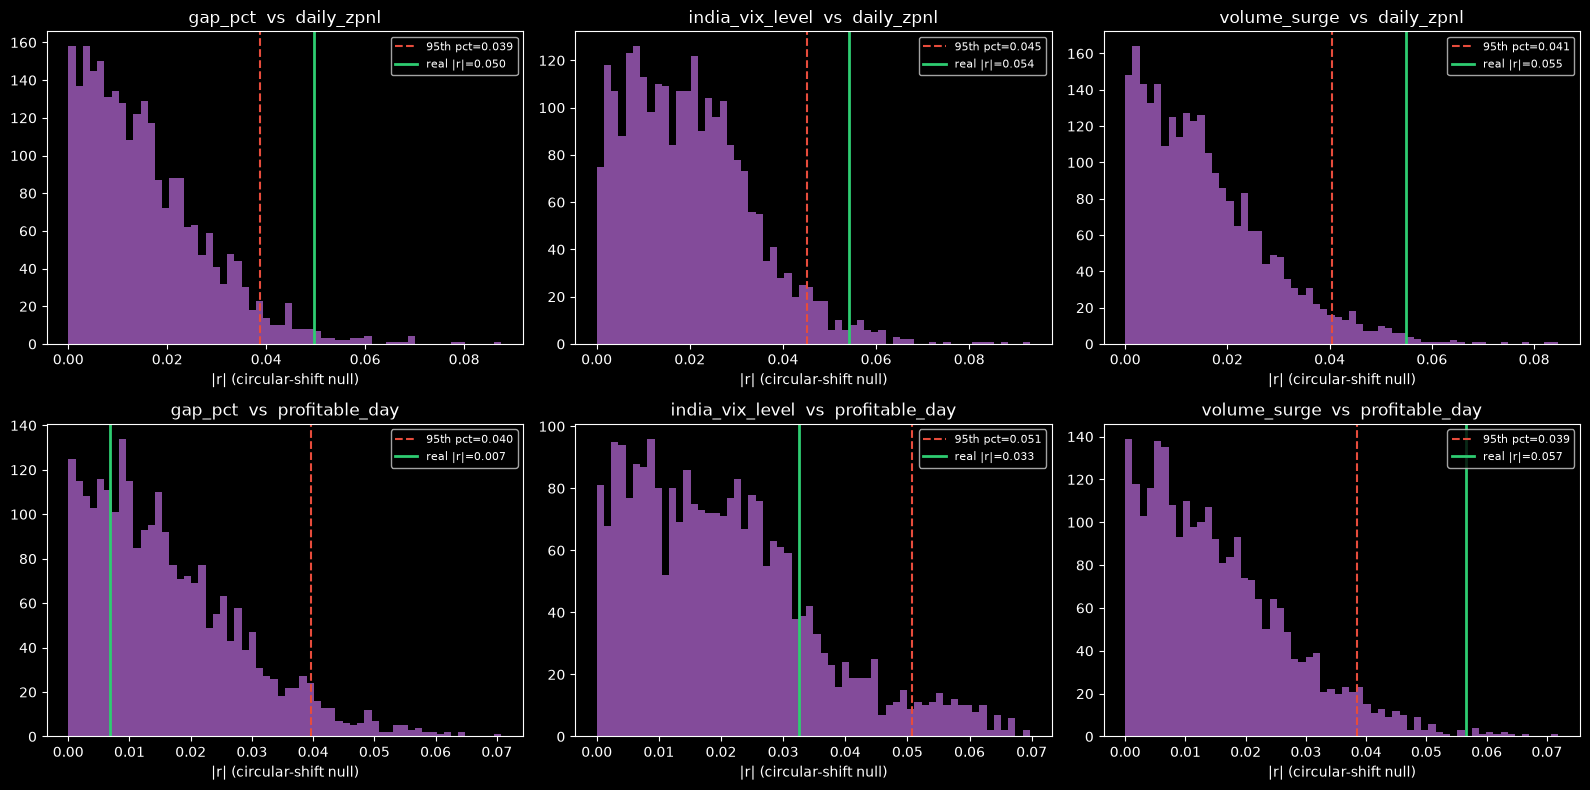

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for row, target in enumerate(['daily_zpnl', 'profitable_day']):
    for col, f in enumerate(NEW_FEATURES):
        nulls = individual_null_circ[(target, f)]
        real_r = np.corrcoef(daily_new[f].values, daily_new[target].values)[0, 1]
        ceil95 = np.percentile(np.abs(nulls), 95)
        ax = axes[row, col]
        ax.hist(np.abs(nulls), bins=60, color='#9b59b6', alpha=0.85)
        ax.axvline(ceil95, color='#e74c3c', linestyle='--', label=f'95th pct={ceil95:.3f}')
        ax.axvline(abs(real_r), color='#2ecc71', linewidth=2, label=f'real |r|={abs(real_r):.3f}')
        ax.set_title(f'{f}  vs  {target}')
        ax.set_xlabel('|r| (circular-shift null)'); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 3. Combined null-calibration — max-of-N (N = all built candidates, currently 12)

Not max-of-3 (that would under-correct, same mistake flagged in `54c` §3c) — the true
count of "looks" available is every candidate ever built, not just the 3 targeted this
round.

In [5]:
def _pearson_cols(X, y):
    Xc = X - X.mean(axis=0); yc = y - y.mean()
    num = (Xc * yc[:, None]).sum(axis=0)
    den = np.sqrt((Xc**2).sum(axis=0) * (yc**2).sum())
    return num / den

daily_all = daily.dropna(subset=ALL_CANDIDATES + ['daily_zpnl']).reset_index(drop=True)
Xall = daily_all[ALL_CANDIDATES].values
N_CAND = len(ALL_CANDIDATES)
print(f'{len(daily_all):,} days retained (all {N_CAND} candidates + target non-null)')

def combined_null_N_circular(df, X, target_col):
    y = df[target_col].values.astype(float)
    n = len(y)
    max_abs_r = np.empty(n - 1)
    for shift in range(1, n):
        max_abs_r[shift - 1] = np.abs(_pearson_cols(X, np.roll(y, shift))).max()
    return max_abs_r

combined_null_N_circ = {t: combined_null_N_circular(daily_all, Xall, t) for t in ['daily_zpnl', 'profitable_day']}
for t, nulls in combined_null_N_circ.items():
    c95, c99 = np.percentile(nulls, [95, 99])
    print(f'  {t:16s} max-of-{N_CAND} ceil95={c95:.4f}  ceil99={c99:.4f}')


2,453 days retained (all 12 candidates + target non-null)


  daily_zpnl       max-of-12 ceil95=0.0629  ceil99=0.0812
  profitable_day   max-of-12 ceil95=0.0610  ceil99=0.0708


## 4. The real screen — actual r for each (feature, target) pair, both ceiling scopes shown

In [6]:
results = []
for target_col in ['daily_zpnl', 'profitable_day']:
    for f in NEW_FEATURES:
        r_real = np.corrcoef(daily_new[f].values, daily_new[target_col].values)[0, 1]

        ind_nulls_c = individual_null_circ[(target_col, f)]
        ind_ceil95_c, ind_ceil99_c = np.percentile(np.abs(ind_nulls_c), [95, 99])
        emp_p_ind_circ = (np.abs(ind_nulls_c) >= abs(r_real)).mean()

        ind_nulls_i = individual_null_iid_dist[(target_col, f)]
        emp_p_ind_iid = (np.abs(ind_nulls_i) >= abs(r_real)).mean()

        # r for this feature on the max-of-N (wider, slightly different) sample
        r_wide = np.corrcoef(daily_all[f].values, daily_all[target_col].values)[0, 1]
        combN_nulls = combined_null_N_circ[target_col]
        combN_ceil95, combN_ceil99 = np.percentile(combN_nulls, [95, 99])

        n = len(daily_new)
        t_stat = r_real * np.sqrt((n - 2) / (1 - r_real**2))
        textbook_p = 2 * stats.t.sf(abs(t_stat), n - 2)

        results.append(dict(
            target=target_col, feature=f, r=round(r_real, 4),
            clears_individual_95_circ=abs(r_real) > ind_ceil95_c,
            clears_individual_99_circ=abs(r_real) > ind_ceil99_c,
            emp_p_individual_circ=round(emp_p_ind_circ, 4),
            emp_p_individual_iid=round(emp_p_ind_iid, 4),  # comparison only
            r_wide_sample=round(r_wide, 4),
            clears_maxN_95_circ=abs(r_wide) > combN_ceil95,
            clears_maxN_99_circ=abs(r_wide) > combN_ceil99,
            textbook_p=round(textbook_p, 6),
        ))

results_df = pd.DataFrame(results)
results_df


,target,feature,r,clears_individual_95_circ,clears_individual_99_circ,emp_p_individual_circ,emp_p_individual_iid,r_wide_sample,clears_maxN_95_circ,clears_maxN_99_circ,textbook_p
0,daily_zpnl,gap_pct,-0.0496,True,False,0.0146,0.0102,-0.0625,False,False,0.012460
1,daily_zpnl,india_vix_level,0.0542,True,False,0.0193,0.0084,0.0519,False,False,0.006348
2,daily_zpnl,volume_surge,-0.0549,True,True,0.0087,0.0058,-0.0506,False,False,0.005718
3,profitable_day,gap_pct,-0.0068,False,False,0.7429,0.7216,-0.0137,False,False,0.733109
4,profitable_day,india_vix_level,0.0326,False,False,0.1818,0.0926,0.0290,False,False,0.100660
5,profitable_day,volume_surge,-0.0566,True,True,0.0051,0.0040,-0.0486,False,False,0.004373


## 5. Visual sanity check — scatter + quartile-bucket comparison

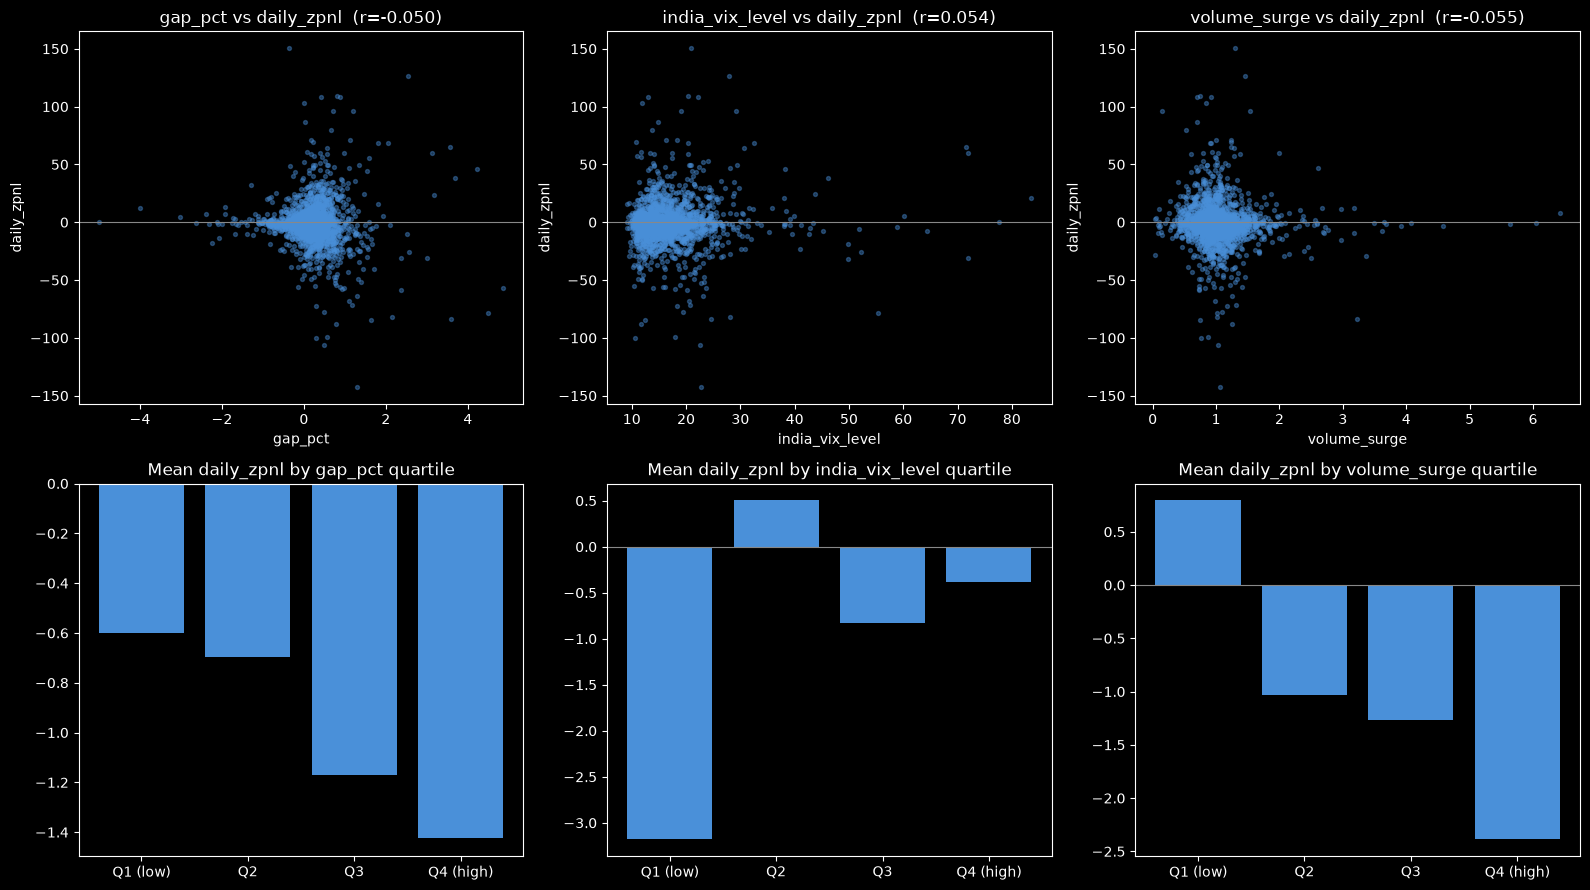

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, f in enumerate(NEW_FEATURES):
    axes[0, col].scatter(daily_new[f], daily_new['daily_zpnl'], s=8, alpha=0.4, color='#4a90d9')
    axes[0, col].axhline(0, color='#888', linewidth=0.8)
    axes[0, col].set_xlabel(f); axes[0, col].set_ylabel('daily_zpnl')
    r_val = results_df[(results_df.feature == f) & (results_df.target == 'daily_zpnl')]['r'].iloc[0]
    axes[0, col].set_title(f'{f} vs daily_zpnl  (r={r_val:.3f})')

    daily_new[f'{f}_q'] = pd.qcut(daily_new[f], 4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
    bucket_means = daily_new.groupby(f'{f}_q', observed=True)['daily_zpnl'].mean()
    axes[1, col].bar(bucket_means.index.astype(str), bucket_means.values, color='#4a90d9')
    axes[1, col].axhline(0, color='#888', linewidth=0.8)
    axes[1, col].set_title(f'Mean daily_zpnl by {f} quartile')
plt.tight_layout()
plt.show()


## 6. Theory check — does each candidate have a plausible mechanism, independent of r?

Per the lesson from `nifty_trend_10d` (high acf1, high raw r-adjacent plausibility, but
theoretically dead on weak-form efficiency) -- a feature needs a real mechanism, not
just a number that clears a bar, before it's trustworthy.

- **`india_vix_level`**: strong grounding. A market-wide implied-volatility state
  variable -- the single most canonical "regime" indicator in finance. Forward-looking
  (option-market-implied expectation of near-term volatility), NOT the same
  second-moment mechanism as `dispersion` (backward-looking realized measure) or
  `nifty_trend_10d` (first-moment/directional, dead by weak-form efficiency). Outside
  weak-form efficiency's scope, same reasoning that rescues dispersion/volume.

- **`volume_surge`**: reasonable grounding, same family as `dispersion` -- a magnitude/
  activity feature (how much is trading), not a directional one. Volume clustering is a
  well-documented stylized fact (mixture-of-distributions hypothesis, volume-volatility
  co-movement) -- outside weak-form efficiency's scope for the same reason dispersion is.

- **`gap_pct`**: mixed case, needs care. An overnight gap (today's open vs yesterday's
  close) is directional (first-moment), which on its face looks more like
  `nifty_trend_10d` than like dispersion/volume -- concerning, since that's the dead
  category. BUT there's a distinct, narrower theoretical case for gaps specifically:
  overnight gaps can reflect information (after-hours news, global market moves) that
  hasn't yet been fully arbitraged into the FIRST few minutes of trading -- a real,
  separately-studied market-microstructure phenomenon (gap-fill/gap-continuation
  literature), distinct from "does yesterday's 10-day trend predict today's return"
  (which weak-form efficiency directly rules out). Worth screening on its own mechanism
  merits, not guilty by association with trend -- but treat any surviving r with more
  skepticism than india_vix_level/volume_surge, given the directional/first-moment
  category it sits in.

## 7. Verdict

In [8]:
print(results_df.to_string(index=False))
print()
passed = results_df[results_df.clears_individual_95_circ]
print(f'Clears individual circular-shift 95th: {len(passed)} of {len(results_df)} pairs')
if len(passed):
    print(passed[['target','feature','r','clears_individual_99_circ','emp_p_individual_circ',
                   'clears_maxN_95_circ','clears_maxN_99_circ']].to_string(index=False))
print()
passed_both = results_df[results_df.clears_individual_95_circ & results_df.clears_maxN_95_circ]
print(f'Clears BOTH individual AND max-of-N (12) 95th: {len(passed_both)} of {len(results_df)} pairs')
print()
if len(passed_both) == 0:
    print('None of the 3 new candidates survive both the individual AND widened-scope circular-')
    print('shift checks -- same fate as dispersion under the fully-corrected test. No OOS gate')
    print('test warranted for any of them at this time.')
else:
    print('Candidate(s) above survive the full statistical screen -- next step is an OOS gate')
    print('test (chronological 70/30 split, cutoff from TRAIN only) before any entry-logic build,')
    print('same discipline dispersion went through.')


        target         feature       r  clears_individual_95_circ  clears_individual_99_circ  emp_p_individual_circ  emp_p_individual_iid  r_wide_sample  clears_maxN_95_circ  clears_maxN_99_circ  textbook_p
    daily_zpnl         gap_pct -0.0496                       True                      False                 0.0146                0.0102        -0.0625                False                False    0.012460
    daily_zpnl india_vix_level  0.0542                       True                      False                 0.0193                0.0084         0.0519                False                False    0.006348
    daily_zpnl    volume_surge -0.0549                       True                       True                 0.0087                0.0058        -0.0506                False                False    0.005718
profitable_day         gap_pct -0.0068                      False                      False                 0.7429                0.7216        -0.0137                Fals